# Dependencies

In [1]:
import os 
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.src.layers import Dropout

# Load data

In [3]:
path = "C:\\python\\LEGO Classifier\\data\\archive\\LEGO brick images v1"

In [4]:
img_size = (155,155)
batch_size = 32

In [5]:
train_data = keras.utils.image_dataset_from_directory(
    path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_data = keras.utils.image_dataset_from_directory(
    path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 6379 files belonging to 16 classes.
Using 5104 files for training.
Found 6379 files belonging to 16 classes.
Using 1275 files for validation.


In [6]:
class_names = train_data.class_names
print(f"{len(class_names)} classes: {class_names}")

16 classes: ['11214 Bush 3M friction with Cross axle', '18651 Cross Axle 2M with Snap friction', '2357 Brick corner 1x2x2', '3003 Brick 2x2', '3004 Brick 1x2', '3005 Brick 1x1', '3022 Plate 2x2', '3023 Plate 1x2', '3024 Plate 1x1', '3040 Roof Tile 1x2x45deg', '3069 Flat Tile 1x2', '32123 half Bush', '3673 Peg 2M', '3713 Bush for Cross Axle', '3794 Plate 1X2 with 1 Knob', '6632 Technic Lever 3M']


In [7]:
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Build model

In [8]:
model = keras.Sequential([
    keras.Input(shape=(*img_size, 3)),
    keras.layers.Rescaling(1./255),
    keras.layers.Conv2D(32, 3, activation='relu'),
    keras.layers.SeparableConv2D(32, 3, activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(len(class_names), activation='softmax')
])

model.add(Dropout(0.5))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 155, 155, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 153, 153, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 151, 151, 32)   │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 180000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,040,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,044,432 (87.91 MB)

 Trainable params: 23,044,432 (87.91 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 87s 508ms/step - accuracy: 0.2326 - loss: 7.1238 - val_accuracy: 0.6298 - val_loss: 5.4059
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 80s 502ms/step - accuracy: 0.3791 - loss: 4.2569 - val_accuracy: 0.7090 - val_loss: 5.7176
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 80s 498ms/step - accuracy: 0.4118 - loss: 3.5307 - val_accuracy: 0.7059 - val_loss: 8.1619
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 80s 498ms/step - accuracy: 0.4265 - loss: 3.1810 - val_accuracy: 0.7686 - val_loss: 5.4679
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 81s 504ms/step - accuracy: 0.4389 - loss: 2.8541 - val_accuracy: 0.7929 - val_loss: 5.9598
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 78s 490ms/step - accuracy: 0.4465 - loss: 2.6579 - val_accuracy: 0.7882 - val_loss: 6.4171
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 79s 492ms/step - accuracy: 0.4496 - loss: 2.5850 - val_accuracy: 0.8047 - val_loss: 7.0116
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 78s 488ms/step - accuracy: 0.4653 - loss: 2

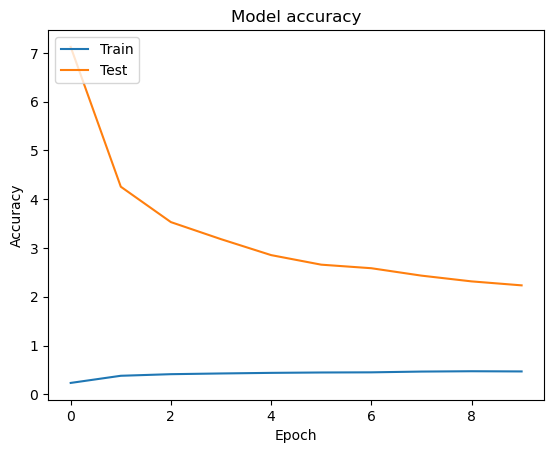

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()